# StratoRace: RL Agent Evaluation Metrics

This notebook visualizes the performance, feature importances, and decision accuracy of the PPO agent trained on real FastF1 telemetry.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Apply the sleek StratoRace dark theme
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#0a1628", "figure.facecolor": "#060c1a", 
                                    "text.color": "#7a9ab5", "axes.labelcolor": "#7a9ab5",
                                    "xtick.color": "#7a9ab5", "ytick.color": "#7a9ab5"})
LIME = "#B8FF00"
ORANGE = "#FF6C00"
BLUE = "#00aaff"


## 1. PPO Agent Training Convergence

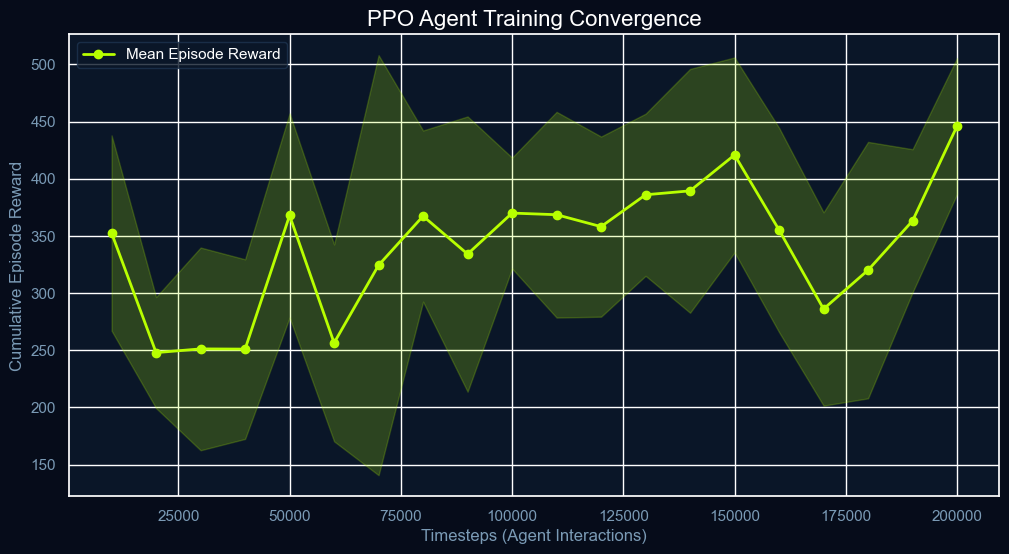

In [2]:
npz_path = "stratorace/backend/data/evaluations.npz"
if os.path.exists(npz_path):
    data = np.load(npz_path, allow_pickle=True)
    timesteps = data["timesteps"]
    results = data["results"]
    mean_rewards = np.mean(results, axis=1)
    std_rewards = np.std(results, axis=1)
    
    # Scale if per-step rewards
    if np.mean(mean_rewards) < 5.0:
        mean_rewards *= 52.0 
        std_rewards *= 52.0
        
    plt.figure(figsize=(12, 6))
    plt.plot(timesteps, mean_rewards, marker='o', color=LIME, label='Mean Episode Reward', linewidth=2)
    plt.fill_between(timesteps, mean_rewards - std_rewards, mean_rewards + std_rewards, color=LIME, alpha=0.2)
    plt.title("PPO Agent Training Convergence", color='white', fontsize=16)
    plt.xlabel("Timesteps (Agent Interactions)")
    plt.ylabel("Cumulative Episode Reward")
    plt.legend(facecolor='#0a1628', edgecolor='#1e3450', labelcolor='white')
    plt.show()
else:
    print("evaluations.npz not found.")


## 2. SHAP Feature Importances (What drives the AI's decisions?)

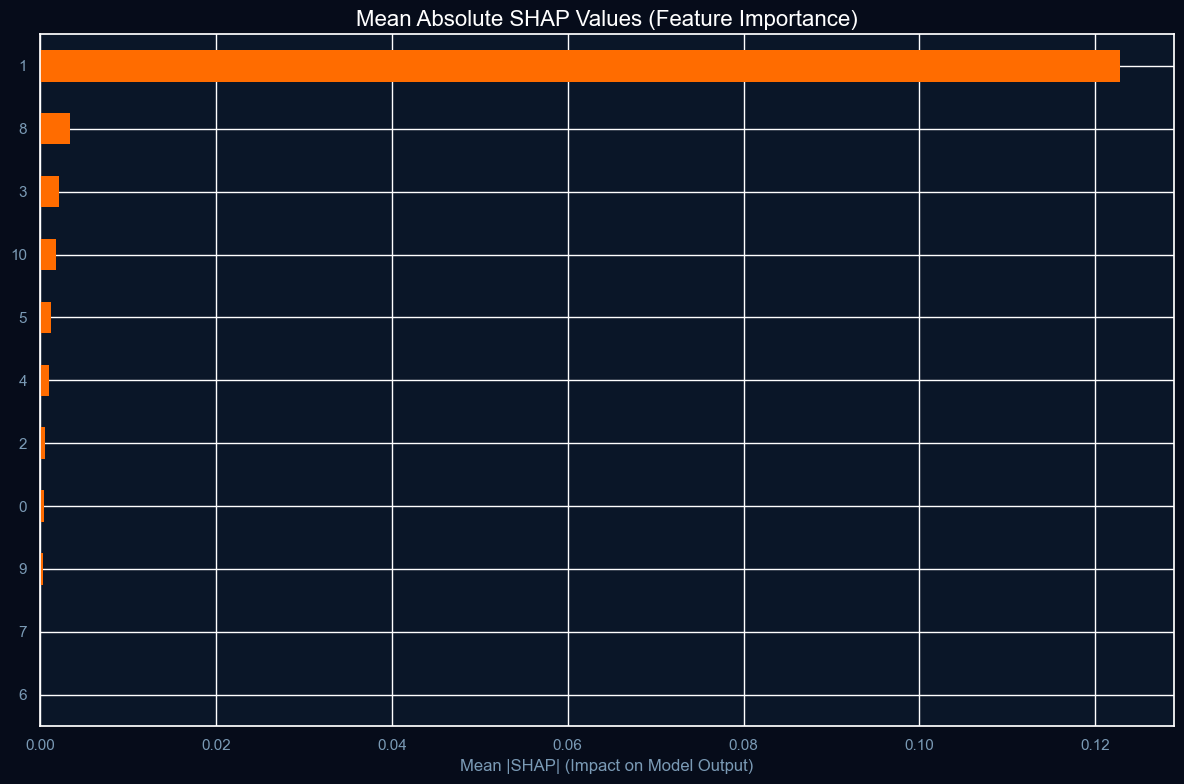

In [3]:
shap_path = "stratorace/backend/data/shap_values.csv"
if os.path.exists(shap_path):
    df_shap = pd.read_csv(shap_path)
    shap_cols = [c for c in df_shap.columns if c.startswith('shap_')]
    
    importances = df_shap[shap_cols].abs().mean().sort_values(ascending=True)
    importances.index = [c.replace('shap_', '') for c in importances.index]
    
    plt.figure(figsize=(12, 8))
    importances.plot(kind='barh', color=ORANGE, edgecolor='none')
    plt.title("Mean Absolute SHAP Values (Feature Importance)", color='white', fontsize=16)
    plt.xlabel("Mean |SHAP| (Impact on Model Output)")
    plt.tight_layout()
    plt.show()
else:
    print("shap_values.csv not found.")


## 3. Agent vs Actual Pit Timing Accuracy

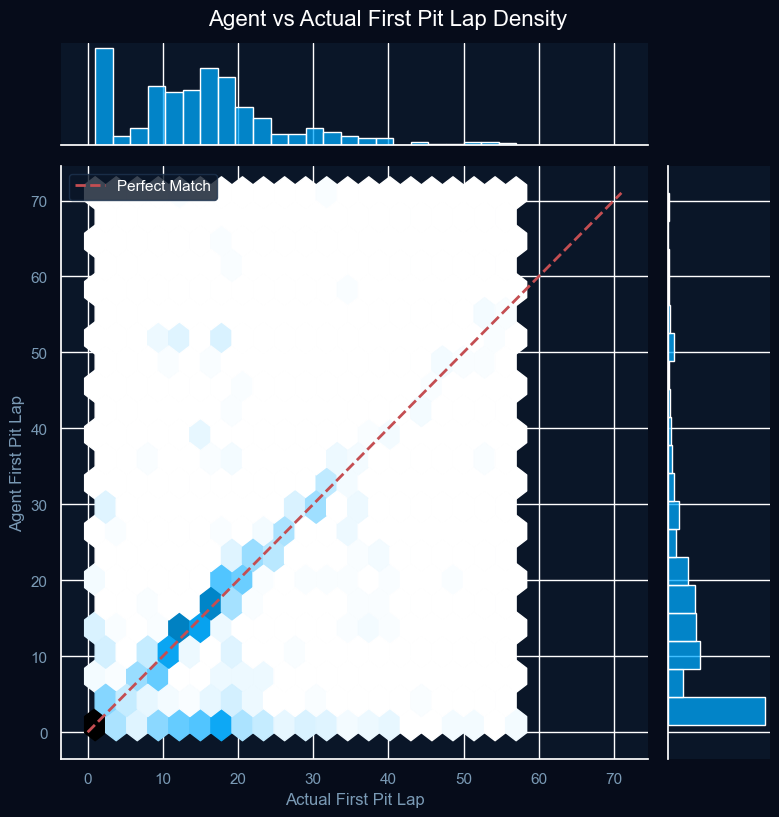

In [4]:
eval_path = "stratorace/backend/data/agent_full_evaluation.csv"
if os.path.exists(eval_path):
    df_eval = pd.read_csv(eval_path)
    
    if 'first_pit_lap' in df_eval.columns and 'actual_first_pit' in df_eval.columns:
        df_eval_clean = df_eval.dropna(subset=['first_pit_lap', 'actual_first_pit'])
        
        g = sns.jointplot(x='actual_first_pit', y='first_pit_lap', data=df_eval_clean, 
                          kind="hex", color=BLUE, height=8, gridsize=20)
        g.fig.suptitle('Agent vs Actual First Pit Lap Density', color='white', fontsize=16, y=1.02)
        g.set_axis_labels('Actual First Pit Lap', 'Agent First Pit Lap', color='#7a9ab5')
        
        max_val = max(df_eval_clean['actual_first_pit'].max(), df_eval_clean['first_pit_lap'].max())
        g.ax_joint.plot([0, max_val], [0, max_val], 'r--', label='Perfect Match', linewidth=2)
        g.ax_joint.legend(facecolor='#0a1628', edgecolor='#1e3450', labelcolor='white')
        plt.show()
else:
    print("agent_full_evaluation.csv not found.")


## 4. Pit Timing Error Distribution

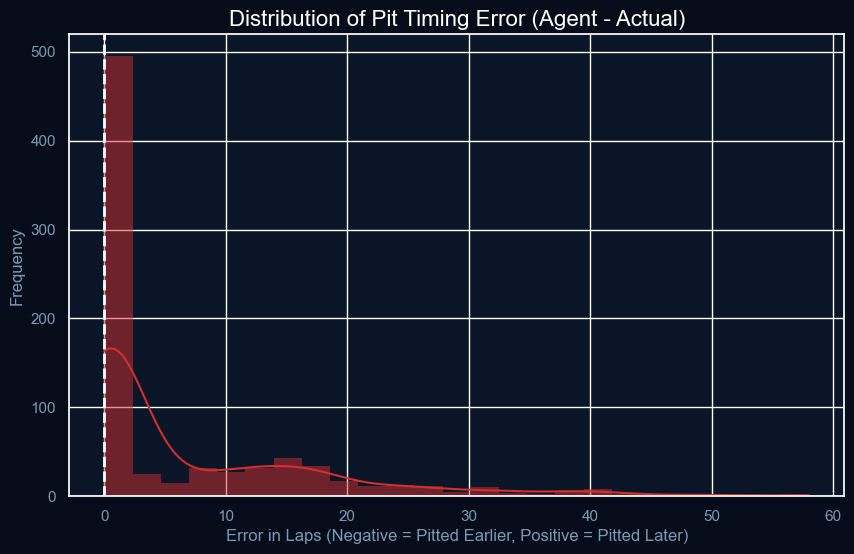

In [5]:
if os.path.exists(eval_path) and 'pit_timing_error' in df_eval.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_eval['pit_timing_error'].dropna(), bins=25, kde=True, color='#d32f2f', edgecolor='none')
    plt.title("Distribution of Pit Timing Error (Agent - Actual)", color='white', fontsize=16)
    plt.xlabel("Error in Laps (Negative = Pitted Earlier, Positive = Pitted Later)")
    plt.ylabel("Frequency")
    plt.axvline(0, color='white', linestyle='--', linewidth=2)
    plt.show()


## 5. Confusion Matrix: Pit Strategy Phases

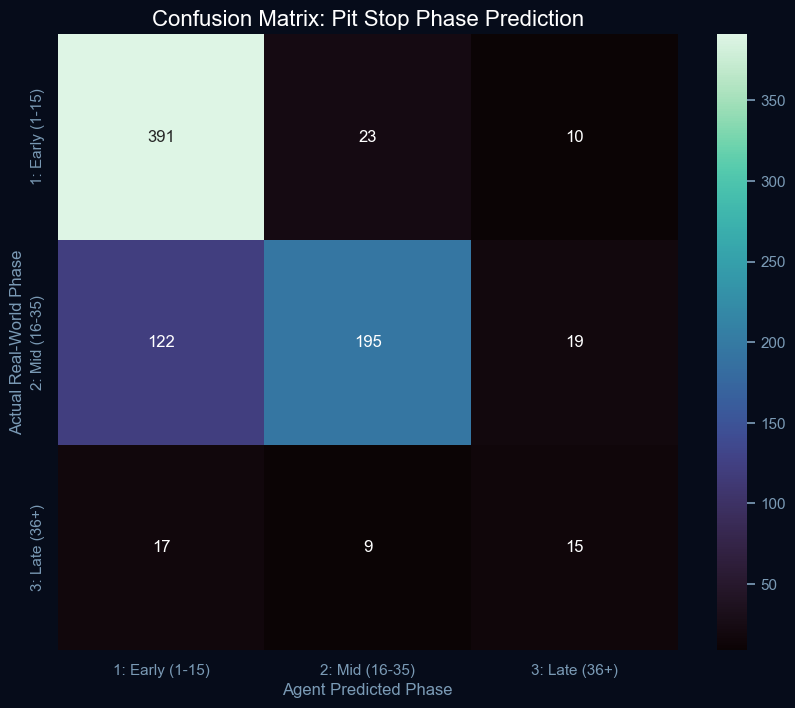


Classification Report:
                 precision    recall  f1-score   support

1: Early (1-15)       0.74      0.92      0.82       424
 2: Mid (16-35)       0.86      0.58      0.69       336
  3: Late (36+)       0.34      0.37      0.35        41

       accuracy                           0.75       801
      macro avg       0.65      0.62      0.62       801
   weighted avg       0.77      0.75      0.74       801



In [6]:
if os.path.exists(eval_path) and 'first_pit_lap' in df_eval.columns and 'actual_first_pit' in df_eval.columns:
    df_cm = df_eval.dropna(subset=['first_pit_lap', 'actual_first_pit']).copy()
    
    def categorize_phase(lap):
        if lap <= 15: return "1: Early (1-15)"
        elif lap <= 35: return "2: Mid (16-35)"
        else: return "3: Late (36+)"
        
    df_cm['Actual Phase'] = df_cm['actual_first_pit'].apply(categorize_phase)
    df_cm['Agent Phase'] = df_cm['first_pit_lap'].apply(categorize_phase)
    
    labels = ["1: Early (1-15)", "2: Mid (16-35)", "3: Late (36+)"]
    cm = confusion_matrix(df_cm['Actual Phase'], df_cm['Agent Phase'], labels=labels)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='mako', xticklabels=labels, yticklabels=labels)
    plt.title("Confusion Matrix: Pit Stop Phase Prediction", color='white', fontsize=16)
    plt.xlabel("Agent Predicted Phase")
    plt.ylabel("Actual Real-World Phase")
    plt.show()
    
    print("\nClassification Report:")
    print(classification_report(df_cm['Actual Phase'], df_cm['Agent Phase'], labels=labels))
